In [1]:
import plot_helper_functions as hf
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pickle
import seaborn as sns
from matplotlib import gridspec


In [2]:
# settings
non_feature_cols = ['SMILES', 'MP', 'MP_label', 'Type']
figure_output_dir = "../Figures/final_figures/"
data_types = ['L', 'H', 'All']
color_scheme = {
    'L': '#4c72b0', 
    'H': '#dd8452',
    'All': '#55a868', 
    'Purple': '#8172b3',
    'Red': "#e74c3c",
    'Extra': '#4d4d4d'}

# Figure 1 (RFE feature selection)

In [3]:
figure_1_data_path = '../1_feature_engineering/feature_engineering_dict.pkl'
figure_1_data = pd.read_pickle(figure_1_data_path)

  [L] Optimal Feature Set: 89 features, Best RMSE: 34.1129
  [H] Optimal Feature Set: 55 features, Best RMSE: 28.2607
  [All] Optimal Feature Set: 83 features, Best RMSE: 37.6197


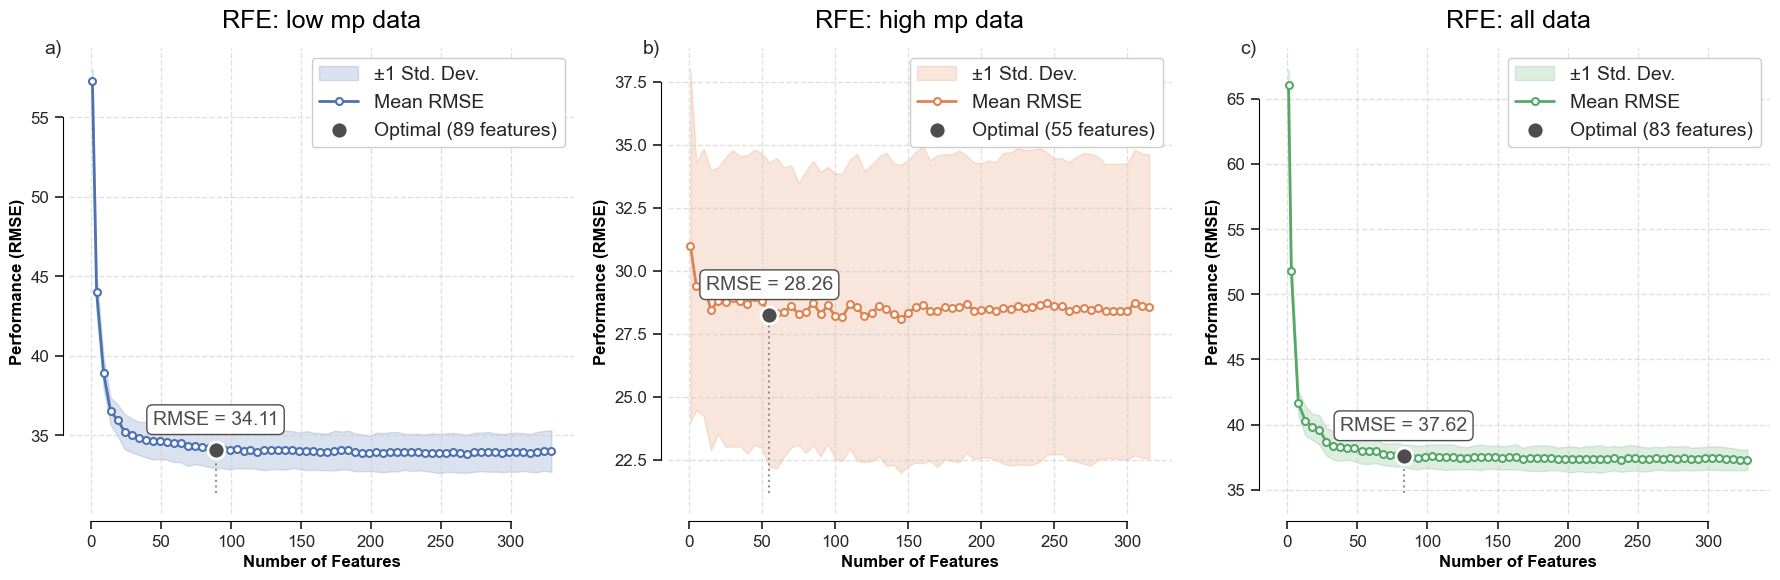

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, data_type in enumerate(data_types):
    hf.RFE_plot(figure_1_data, ann = f'{chr(97+i)})', tolerance=0.01, data_type=data_type, ax=axes[i], color_scheme=color_scheme)
plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_1_rfe.png', dpi=300)


# Figure 2 (model evaluation)

In [5]:
best_model_path = '../2_model_development/best_model_LGB_'
hp_tuning_results_path = '../2_model_development/model_development_results_LGB_'
figure_2_results_path = '../3_model_evaluation/model_evaluation_results_LGB_'

In [6]:
best_models = {}
for data_type in data_types:
    best_models[data_type] = joblib.load(best_model_path + data_type + '.joblib')

In [7]:
hp_tuning_results = {}
for data_type in data_types:
    hp_tuning_results[data_type] = pickle.load(open(hp_tuning_results_path + data_type + '.pkl', 'rb'))


In [8]:
figure_2_results = {}
for data_type in data_types:
    figure_2_results[data_type] = pd.read_csv(figure_2_results_path + data_type + '.csv')

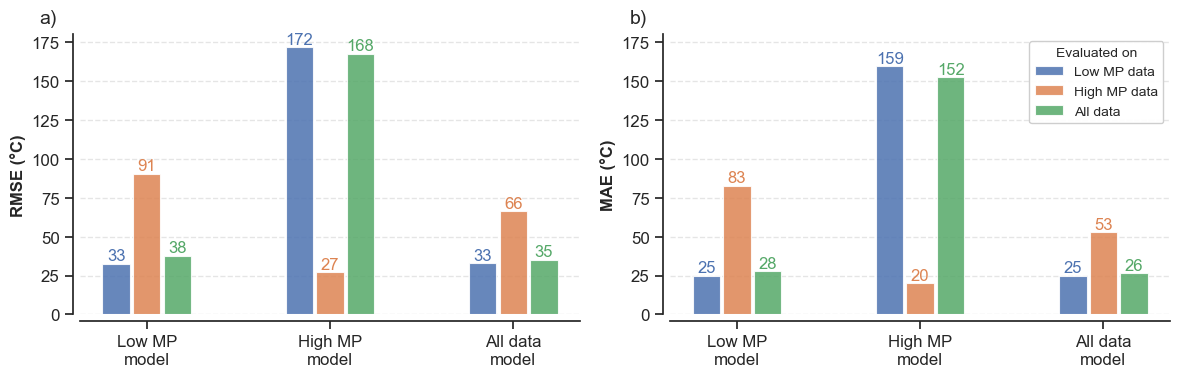

In [9]:
metrics = ['RMSE', 'MAE']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# sns.set_theme(style="ticks", font_scale=1.1)
for i, metric in enumerate(metrics):
    hf.model_eval_plot(figure_2_results, metric, ax=axes[i], color_scheme=color_scheme,
                    ann=f'{chr(97+i)})', show_legend=(i == len(metrics) - 1))
plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_2_model_eval.png', dpi=300)

# Figure 3 (L/H MP data analysis)

In [10]:
figure_3_all_data_path = '../0_data/processed_data/data_with_all_features_scaled.parquet'
figure_3_L_data_path = '../0_data/processed_data/data_with_selected_features_LGB_L.parquet'
figure_3_H_data_path = '../0_data/processed_data/data_with_selected_features_LGB_H.parquet'

In [11]:
H_cols = pd.read_parquet(figure_3_H_data_path).columns.tolist()
L_cols = pd.read_parquet(figure_3_L_data_path).columns.tolist()

# combine the two column lists and remove duplicates
combined_cols = list(dict.fromkeys(H_cols + L_cols))

print(f"H model features: {len(H_cols)}")
print(f"L model features: {len(L_cols)}")
print(f"Combined features: {len(combined_cols)}")

figure_3_data_ = pd.read_parquet(figure_3_all_data_path)[combined_cols]
figure_3_data = figure_3_data_[figure_3_data_['Type'] == 'Train']

print(f"Figure 3 data shape: {figure_3_data.shape}")

H model features: 59
L model features: 93
Combined features: 100
Figure 3 data shape: (12054, 100)


/Users/zeqing/0_Github/melting_point_2026/9_figures/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/zeqing/0_Github/melting_point_2026/9_figures/plot_helper_functions.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/Users/zeqing/0_Github/melting_point_2026/9_figures/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/zeqing/0_Github/melting_point_2026

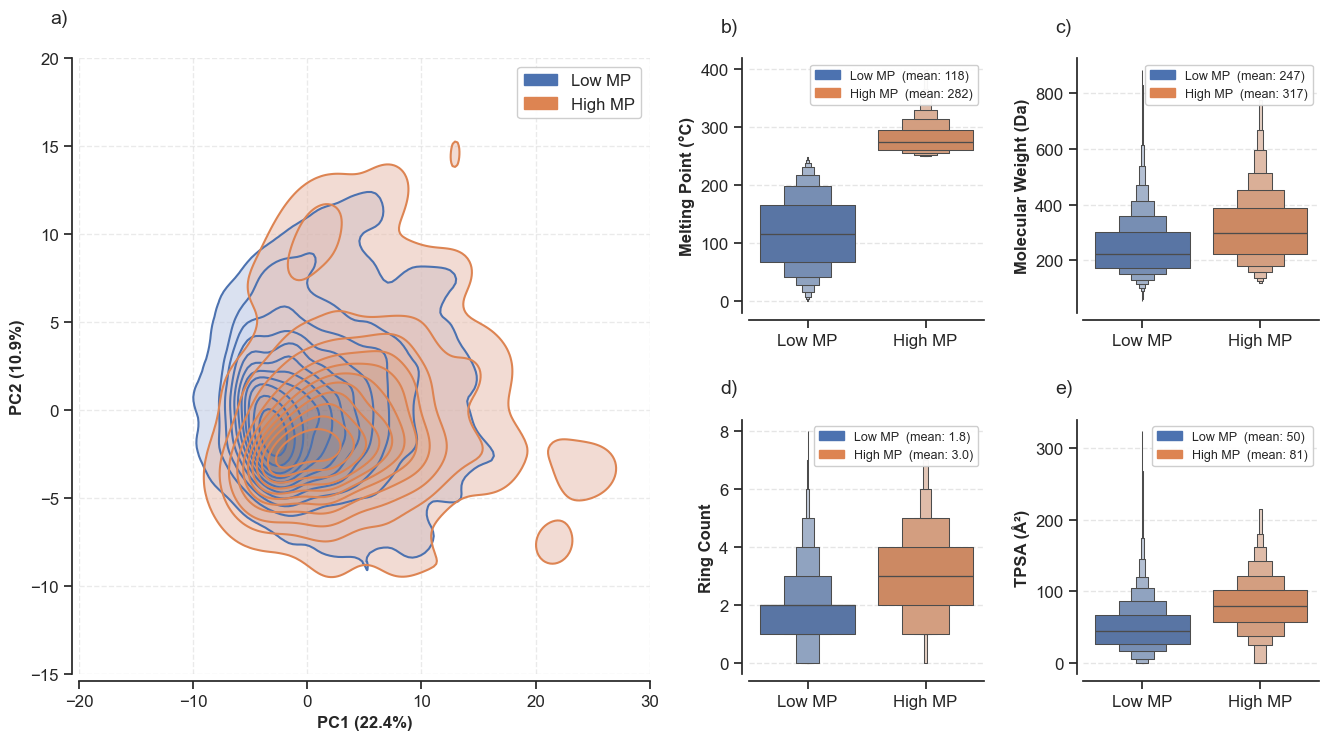

In [12]:
properties = [
    ('MP',   'Melting Point (°C)'),
    ('MW',   'Molecular Weight (Da)'),
    ('RingCount', 'Ring Count'),
    ('TPSA', 'TPSA (Å²)'),
]

sns.set_theme(style="ticks", font_scale=1.1)
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.42, hspace=0.42)

# PCA occupies left 2×2 block — pass SubplotSpec for nested marginals
hf.pca_plot(figure_3_data, 'MP_label',
         gs[0:2, 0:2], fig, color_scheme=color_scheme,
         xlim=[-20, 30], ylim=[-15, 20], ann='a)', show_legend=True, show_marginals=False)

prop_positions = [(0, 2), (0, 3), (1, 2), (1, 3)]
for i, ((row, col), (prop, label)) in enumerate(zip(prop_positions, properties)):
    ax = fig.add_subplot(gs[row, col])
    hf.property_plot(figure_3_data, prop, label, ax=ax, x_col='MP_label',
                  color_scheme=color_scheme, smiles_col='SMILES', show_outliers=False,
                  ann=f'{chr(98+i)})', show_legend=True)

plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_3_pca_properties.png', dpi=300)


# Figure 4 (feature importance analysis)

In [13]:
figure_4_model_path_prefix  = '../2_model_development/'
figure_4_data_prefix = '../3_model_evaluation/model_evaluation_results_'

In [14]:
model_H = joblib.load(f"{figure_4_model_path_prefix}best_model_LGB_H.joblib")
model_L = joblib.load(f"{figure_4_model_path_prefix}best_model_LGB_L.joblib")

In [15]:
data_H  = pd.read_csv(figure_4_data_prefix + "LGB_H.csv")
data_H = data_H[data_H['MP_label'] == 'H']

data_L  = pd.read_csv(figure_4_data_prefix + "LGB_L.csv")
data_L = data_L[data_L['MP_label'] == 'L']

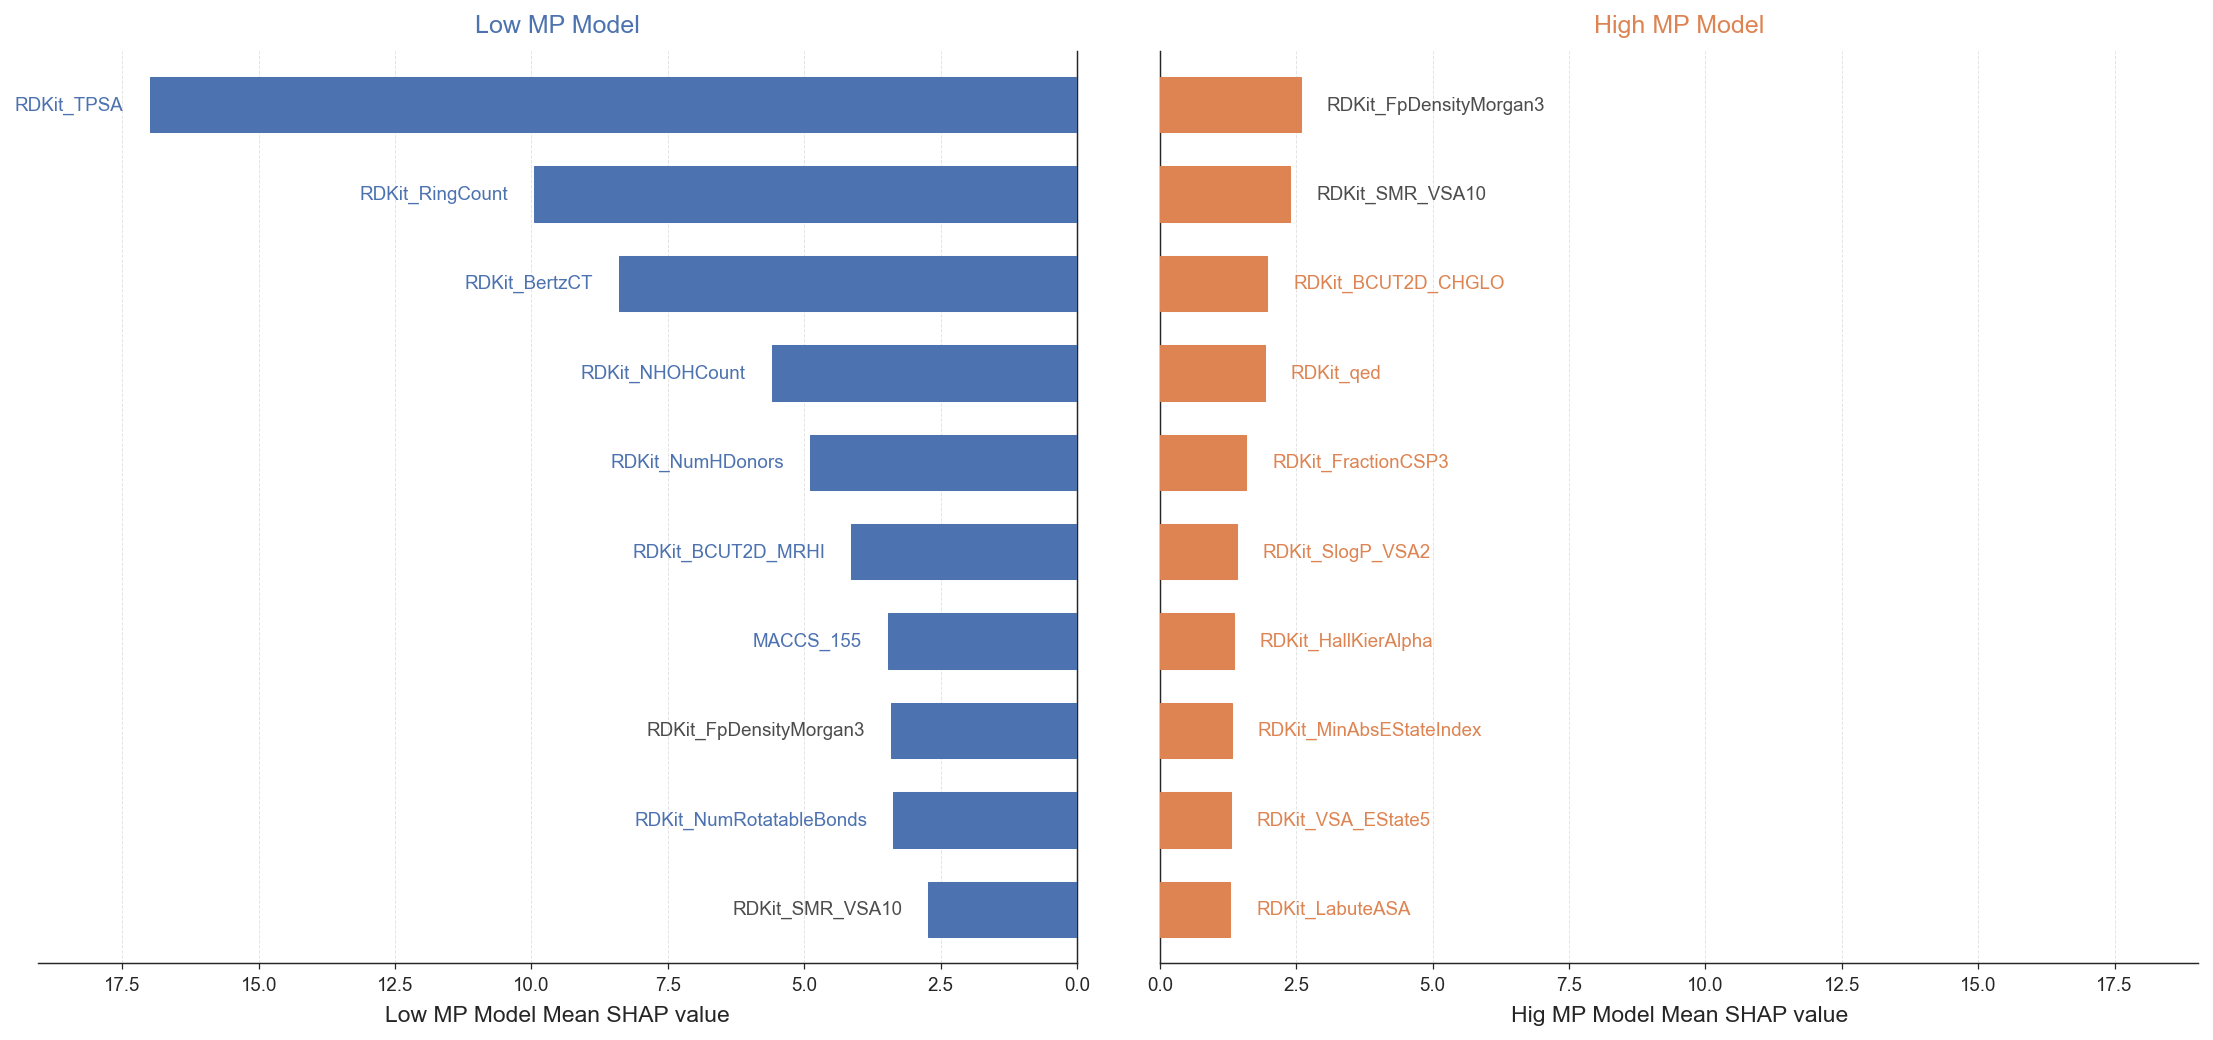

In [16]:
hf.shap_analysis(model_L, model_H, data_L, data_H, n=10)

# Figure 5 (model confidence)

In [17]:
figure_5_data_path = '../5_model_confidence/model_confidence_results_LGB_All.csv'

In [18]:
figure_5_data = pd.read_csv(figure_5_data_path)

/Users/zeqing/0_Github/melting_point_2026/9_figures/plot_helper_functions.py:523: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='MP_label', y='uncertainty', order=group_order,
/Users/zeqing/0_Github/melting_point_2026/9_figures/plot_helper_functions.py:528: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text())


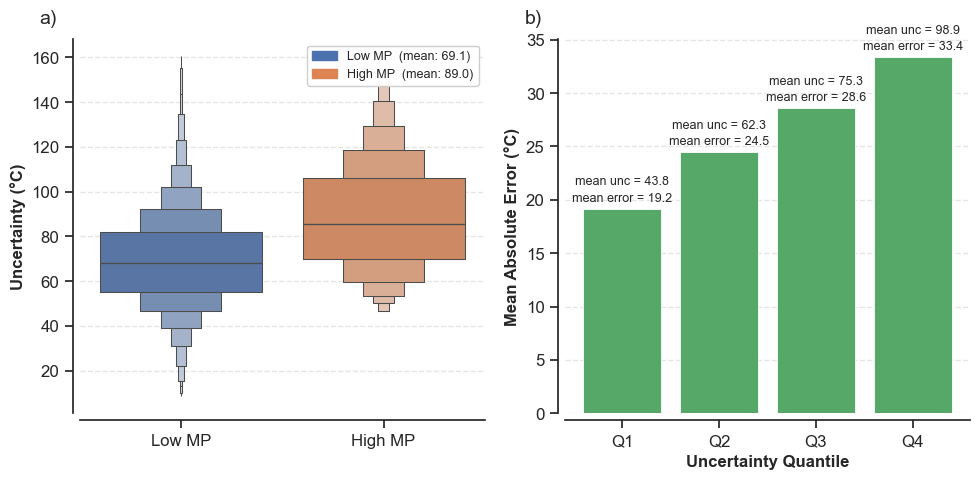

In [19]:
sns.set_theme(style="ticks", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

hf.uncertainty_plot(figure_5_data, ax=axes[0], color_scheme=color_scheme,
                 ann='a)', show_legend=True)
hf.ae_quantile_plot(figure_5_data, ax=axes[1], color_scheme=color_scheme,
                 ann='b)', show_legend=True)

plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_5_uncertainty.png', dpi=300)